# **OCULAR DISEASES DETECTION USING TRANSFER LEARNING APPROCHES**

## **BUSINESS CASE:  BASED ON THE EYE DISEASE IMAGES DATASET WE NEED TO PREDICT THE OCULAR DISEASES**

## **TASK: MULTICLASS CLASSIFICATION**

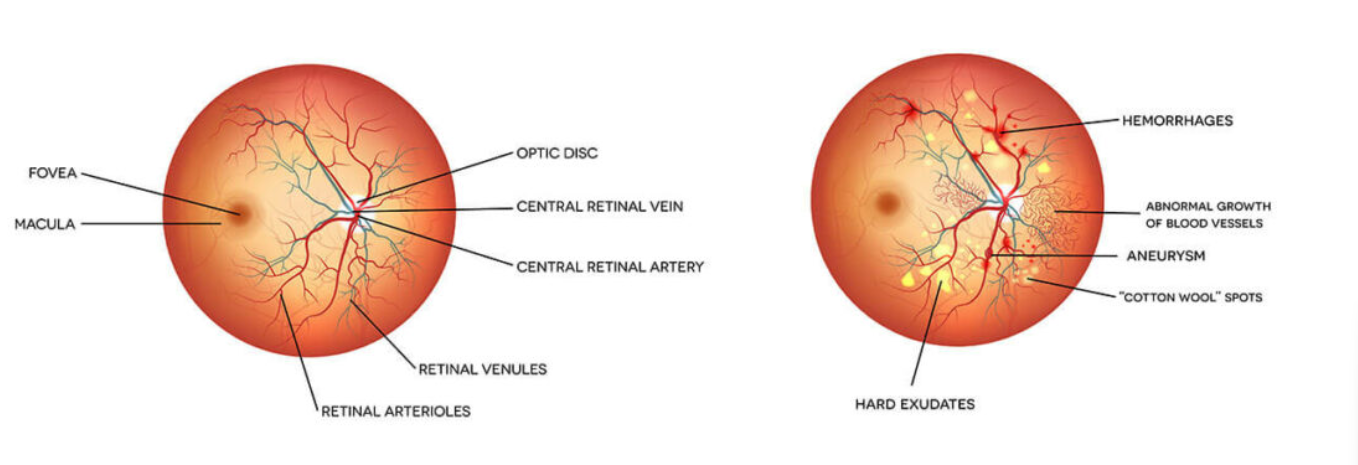

### Eye diseases are important causes of vision loss, and timely and correct diagnosis is essential for effective treatment and prevention of eye diseases. However, manual diagnosis by ophthalmologists may be under-typed and may be contested with limited specialist access.

### This project aims to develop a transfer learning-based AI system to detect and classify a wide range of ocular diseases from medical imaging data, helping to improve diagnostic accuracy, reduce healthcare costs, and provide timely interventions. Utilize different pre-trained deep learning models and embed interpretability techniques to allow explainable predictions to instigate trust and utilization in a clinical context.

## **DATA SUMMARY**

* Dataset contains total 6009 images divided into 4 classes

* 4215 images for training, 1182 images for validation, 612 images for testing.

* Normal: 1008 | Glaucoma: 896 | Diabetic Retinopathy: 1323 | Cataract: 988


## **DEVICE PROJECT INTO MULTIPLE STEPS**
* Image Processing using CLAHE (Contrast Limited Adaptive Histogram Equalization)
* Prepare training, validation and testing set and perfrom Data Augmentation
* Get all classes labels
* Visualise the training images
* Used InceptionV3,DCNN,MobileNetsmall, VGG16, VGG19 and ResNet50 pre-trained model
* Model Compilation
* Model Training
* Model Evaluation
* Model Saving
* Prediction on test data

## **PYTHON IMPLIMENTATION**

In [1]:
#Import Necessary Liabrary
import numpy as np
import cv2
import os
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array,load_img
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Lambda, UpSampling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.vgg16 import VGG16,preprocess_input
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import gradio as gr
from lime import lime_image
from skimage.segmentation import mark_boundaries

# To supress warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **APPLY CLAHE (CONTRAST LIMITED ADAPTIVE HISTOGRAM EQUALIZATION) PROCESSING TO TRAIN, VALIDATION AND TEST DATA AND STORE PROCESS IMAGES INTO DIFFERENT FOLDER**

In [ ]:
data_dir = "/content/drive/MyDrive/Ocular-diseases/data"

train_dir = os.path.join(data_dir, 'train')
valid_dir = os.path.join(data_dir,'valid')
test_dir = os.path.join(data_dir, 'test')

In [ ]:
def clahe_gray(image):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)   # Convert image into lab color space
    l, a, b = cv2.split(lab)                     # split the lab image into its channel
    clahe = cv2.createCLAHE(clipLimit=2, tileGridSize=(8,8))  # Create clahe object
    cl = clahe.apply(l)      # apply clahe to the l channel image
    limg = cv2.merge((cl,a,b))           # Merge clahe enhnaced l channel
    final_image = cv2.cvtColor(limg,cv2.COLOR_LAB2BGR)  # Convert back to bgr color space
    return final_image

In [ ]:
def process_images_in_directory(directory):
    for class_dir in os.listdir(directory):
        class_path = os.path.join(directory, class_dir)
        if os.path.isdir(class_path):
            for img_path in glob(os.path.join(class_path, '*.jpg')):
                image = cv2.imread(img_path) # Read image
                if image is not None:
                    processed_image = clahe_gray(image) # Apply CLAHE
                    output_path = img_path.replace('data', 'clahe_data')
                    os.makedirs(os.path.dirname(output_path), exist_ok=True)
                    cv2.imwrite(output_path, processed_image)
                    print(f"Processed and saved: {output_path}")

In [ ]:
process_images_in_directory(train_dir)
process_images_in_directory(valid_dir)
process_images_in_directory(test_dir)

Streaming output truncated to the last 5000 lines.

Processed and saved: /content/drive/MyDrive/Ocular-diseases/clahe_data/train/Diabetic_retinopathy/10007_left_jpeg_jpg.rf.6961d8e43a8b72e026fd9398b26fb8b9.jpg

Processed and saved: /content/drive/MyDrive/Ocular-diseases/clahe_data/train/Diabetic_retinopathy/10003_left_jpeg_jpg.rf.95f16b78f270427c7deb315e0ab5ee07.jpg

Processed and saved: /content/drive/MyDrive/Ocular-diseases/clahe_data/train/Diabetic_retinopathy/10014_right_jpeg_jpg.rf.9774309f10c19335c36d0968a340f994.jpg

Processed and saved: /content/drive/MyDrive/Ocular-diseases/clahe_data/train/Diabetic_retinopathy/10013_right_jpeg_jpg.rf.39bb12b3418e6e799ad0a4663129fc6d.jpg

Processed and saved: /content/drive/MyDrive/Ocular-diseases/clahe_data/train/Diabetic_retinopathy/1002_right_jpeg_jpg.rf.69ac2828802dad8e17b0b915dd3bffe4.jpg

Processed and saved: /content/drive/MyDrive/Ocular-diseases/clahe_data/train/Diabetic_retinopathy/10029_right_jpeg_jpg.rf.27f96771a1f28085749fd291c020a

## **PREPARE TRAINING, VALIDATION AND TESTING DATA AND PERFORM DATA AGUMENTATION**

In [9]:
clahe_train_dir = r"C:\Users\hp\Downloads\ODD NEW\clahe_data\train"
clahe_val_dir   = r"C:\Users\hp\Downloads\ODD NEW\clahe_data\valid"
clahe_test_dir  = r"C:\Users\hp\Downloads\ODD NEW\clahe_data\test"

In [11]:
train_datagen = ImageDataGenerator(rescale=(1.0/255),
                                   rotation_range=20,
                                   featurewise_center=True,
                                   featurewise_std_normalization=True,
                                   fill_mode='nearest',
                                   zoom_range=0.2,
                                   horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=(1./255))

test_datagen = ImageDataGenerator(rescale=(1./255))


In [13]:
train_set = train_datagen.flow_from_directory(clahe_train_dir,
                                              target_size=(224,224),
                                              batch_size=64,
                                              color_mode='rgb',
                                              class_mode='categorical')

val_set = val_datagen.flow_from_directory(clahe_val_dir,
                                          target_size=(224,224),
                                          batch_size=64,
                                          color_mode='rgb',
                                          class_mode='categorical')

test_set = test_datagen.flow_from_directory(clahe_test_dir,
                                            target_size=(224,224),
                                            batch_size=64,
                                            color_mode='rgb',
                                            class_mode='categorical')

Found 3981 images belonging to 4 classes.
Found 1562 images belonging to 4 classes.
Found 652 images belonging to 4 classes.


In [9]:
# Get classes indices
train_set.class_indices

{'Cataract': 0, 'Diabetic_retinopathy': 1, 'Glaucoma': 2, 'Normal': 3}

### **SEPRATE LABEL FROM TEST SET**

In [10]:
X_test, y_test = next(test_set)

In [11]:
print(X_test.shape)

(64, 224, 224, 3)


In [12]:
print(y_test)

[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]


## **GET CLASS WEIGHTS**

In [13]:
# Get the class labels and their frequencies
from sklearn.utils.class_weight import compute_class_weight

class_labels = train_set.classes
unique_classes = np.unique(class_labels)

In [14]:
print("Class Labels: ", class_labels)
print("Unique Classes:", unique_classes)

Class Labels:  [0 0 0 ... 3 3 3]
Unique Classes: [0 1 2 3]


In [15]:
# Compute the class weights
class_weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=class_labels)

# Create dict of class weights
class_weight_dict = dict(zip(unique_classes, class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 1.0665485829959513, 1: 0.796485260770975, 2: 1.1760602678571428, 3: 1.0453869047619047}


## **VISUALISE THE TRAINING IMAGES**

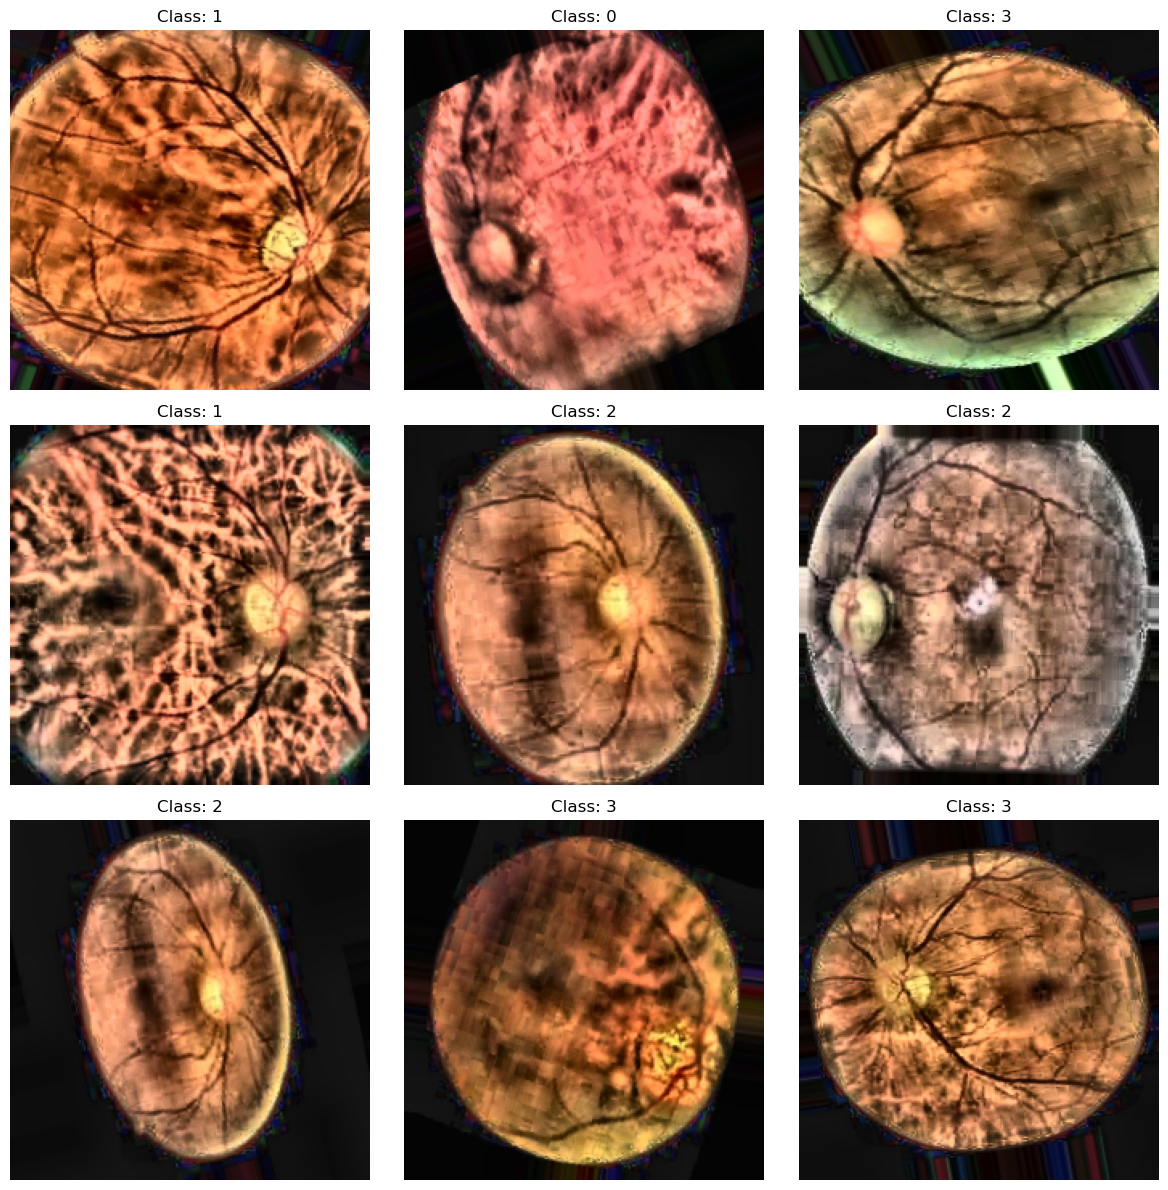

In [16]:
# Seprate the images and labels from training set
img, label = next(train_set)

plt.figure(figsize=(12, 12))
for i in range(9):  # Plotting 9 images
    plt.subplot(3, 3, i + 1)
    plt.imshow(img[i])
    plt.title(f'Class: {label[i].argmax()}')  # Assuming labels are one-hot encoded
    plt.axis('off')
plt.tight_layout()
plt.show()

### **DEEP CONVOLUTIONAL NEURAL NETWORK (DCNN)**

In [5]:
# Create Sequential model
dcnn_model = Sequential()

# Add Convolutional layers along with maxpooling layer
dcnn_model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
dcnn_model.add(MaxPooling2D(pool_size=(2,2)))

dcnn_model.add(Conv2D(64,(3,3),activation='relu'))
dcnn_model.add(MaxPooling2D(pool_size=(2,2)))

dcnn_model.add(Conv2D(128,(3,3),activation='relu'))
dcnn_model.add(MaxPooling2D(pool_size=(2,2)))

dcnn_model.add(Conv2D(256,(3,3),activation='relu'))
dcnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Add Flatten Layer
dcnn_model.add(Flatten())

# Fully Connected layer
dcnn_model.add(Dense(512,activation='relu'))
dcnn_model.add(Dropout(0.5))
dcnn_model.add(Dense(256, activation='relu'))
dcnn_model.add(Dropout(0.5))
dcnn_model.add(Dense(128,activation='relu'))

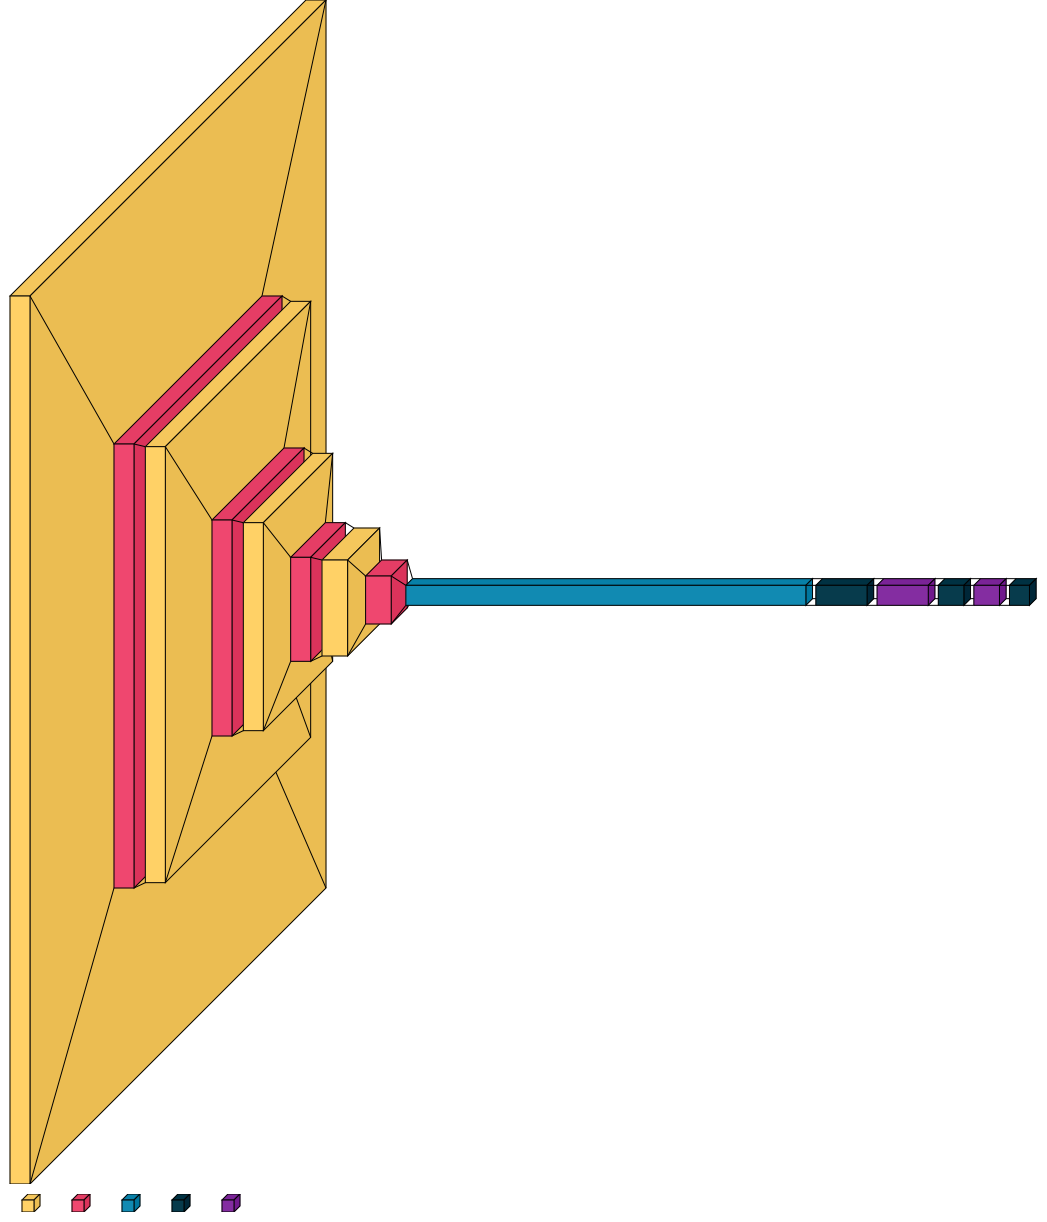

In [6]:
import visualkeras
visualkeras.layered_view(dcnn_model, legend=True)

In [8]:
dcnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 24, 24, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 36864)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │      18,874,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,427,520 (74.11 MB)

 Trainable params: 19,427,520 (74.11 MB)

 Non-trainable params: 0 (0.00 B)

### **COMPILE AND TRAIN MODEL**

In [26]:
# Compile the model with Adam optimizer
dcnn_model.compile(optimizer="adam",
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

In [27]:
# Use ModelCheckPoint and Early stopping to avoid overfitting problem
dcnn_early_stop = EarlyStopping(monitor='val_loss',
                                patience=15,
                                verbose=1)

dcnn_modelCheckpoint = ModelCheckpoint(filepath='D.keras',
                                       monitor='val_loss',
                                       verbose=True,
                                       save_best_only=True)

# fit model for training
dcnn_history = dcnn_model.fit(train_set,
                              epochs=100,
                              validation_data=val_set,
                              class_weight=class_weight_dict,
                              callbacks=[dcnn_early_stop, dcnn_modelCheckpoint])

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2942 - loss: 1.4110
Epoch 1: val_loss improved from inf to 1.05566, saving model to D.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.2948 - loss: 1.4102 - val_accuracy: 0.5355 - val_loss: 1.0557
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5245 - loss: 1.0682
Epoch 2: val_loss improved from 1.05566 to 0.82880, saving model to D.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.5247 - loss: 1.0677 - val_accuracy: 0.6168 - val_loss: 0.8288
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6081 - loss: 0.9165
Epoch 3: val_loss improved from 0.82880 to 0.72933, saving model to D.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.6082 - loss: 0.9162 - val_accuracy: 0.6827 - val_loss: 0.7293
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6338 - loss: 0.8713
Epoch 4: val_loss did not improve from 0.72933
66/66 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - acc

Epoch 26/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8226 - loss: 0.4491
Epoch 26: val_loss did not improve from 0.46386
66/66 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.8225 - loss: 0.4495 - val_accuracy: 0.8071 - val_loss: 0.4883
Epoch 27/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8220 - loss: 0.4482
Epoch 27: val_loss did not improve from 0.46386
66/66 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.8219 - loss: 0.4484 - val_accuracy: 0.7640 - val_loss: 0.5725
Epoch 28/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8165 - loss: 0.4871
Epoch 28: val_loss did not improve from 0.46386
66/66 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.8165 - loss: 0.4870 - val_accuracy: 0.8122 - val_loss: 0.4639
Epoch 29/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8264 - loss: 0.4560
Epoch 29: val_loss did not improve from 0.46386
66/66 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.8264 - loss: 0.4560 - val_accuracy: 0.8071 - val_loss: 0.4743
Epoc

66/66 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.8954 - loss: 0.2786 - val_accuracy: 0.8536 - val_loss: 0.3889
Epoch 52/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9006 - loss: 0.2683
Epoch 52: val_loss improved from 0.38892 to 0.36884, saving model to D.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9005 - loss: 0.2685 - val_accuracy: 0.8714 - val_loss: 0.3688
Epoch 53/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9011 - loss: 0.2790
Epoch 53: val_loss did not improve from 0.36884
66/66 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - accuracy: 0.9011 - loss: 0.2789 - val_accuracy: 0.8511 - val_loss: 0.4076
Epoch 54/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9016 - loss: 0.2688
Epoch 54: val_loss did not improve from 0.36884
66/66 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.9015 - loss: 0.2691 - val_accuracy: 0.8579 - val_loss: 0.3990
Epoch 55/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8923 - loss: 0.3051
Epoch 55: val_loss did 

### **PLOT DCNN MODEL TRAIN ACCURACY & LOSS AS WELL AS VALIDATION ACCURACY LOSS**

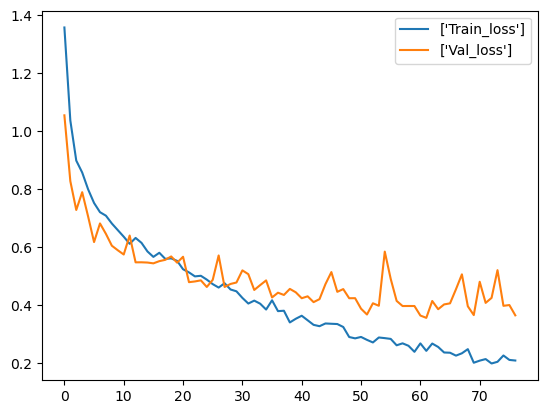

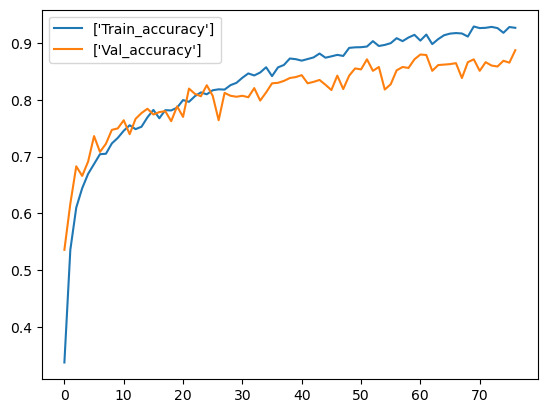

In [28]:
plt.plot(dcnn_history.history['loss'], label=['Train_loss'])
plt.plot(dcnn_history.history['val_loss'], label=['Val_loss'])
plt.legend()
plt.show()
plt.savefig('DCNN_train_val_loss')

plt.plot(dcnn_history.history['accuracy'], label=['Train_accuracy'])
plt.plot(dcnn_history.history['val_accuracy'], label=['Val_accuracy'])
plt.legend()
plt.savefig('DCNN_train_val_accuracy')
plt.show()


In [29]:
train_loss, train_accuracy = dcnn_model.evaluate(train_set)
test_loss, test_accuracy = dcnn_model.evaluate(test_set)
print(f"Train Loss:{train_loss:.4f}")
print(f"Train Accuracy:{train_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9586 - loss: 0.1238
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 814ms/step - accuracy: 0.8916 - loss: 0.3907
Train Loss:0.1278
Train Accuracy:0.9585
Test Loss: 0.3889
Test Accuracy: 0.8954


* DCNN model training accuray is 95.85% and testing accuracy is 89.54%.

### **PREDICTION ON TEST DATA**

In [30]:
# Predict labels for the test set
dcnn_ypred = dcnn_model.predict(X_test)

# Get class labels from predictions
y_pred_labels = np.argmax(dcnn_ypred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 416ms/step


In [31]:
from sklearn.metrics import classification_report, confusion_matrix,f1_score,accuracy_score, recall_score

dcnn_confusion_matrix = confusion_matrix(y_test_labels, y_pred_labels)
print("Confusion Matrix:\n", dcnn_confusion_matrix)

Confusion Matrix:
 [[20  0  0  0]
 [ 0 19  0  2]
 [ 0  0  8  2]
 [ 1  1  0 11]]


In [32]:
# F1 Score
dcnn_f1score = f1_score(y_test_labels, y_pred_labels,average='weighted')
print("F1 Score:", dcnn_f1score*100)

F1 Score: 90.74810056136273


In [33]:
# Classification report
dcnn_report = classification_report(y_test_labels, y_pred_labels)
print("Classification Report:\n", dcnn_report)

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       0.95      0.90      0.93        21
           2       1.00      0.80      0.89        10
           3       0.73      0.85      0.79        13

    accuracy                           0.91        64
   macro avg       0.91      0.89      0.89        64
weighted avg       0.91      0.91      0.91        64



### **MAKE PREDICTION ON DCNN MODEL**

In [28]:
dcnn_y_hat = dcnn_model.predict(test_set)
dcnn_y_hat

10/10 [==============================] - 4s 428ms/step


array([[9.9999297e-01, 1.0844631e-09, 8.6202084e-10, 7.0044662e-06],
       [2.9096962e-05, 2.7672127e-03, 9.5144576e-05, 9.9710864e-01],
       [1.6403737e-27, 1.0000000e+00, 1.0239744e-18, 2.8156753e-11],
       ...,
       [2.9594020e-03, 2.2549691e-02, 1.0803283e-02, 9.6368766e-01],
       [1.2662365e-04, 3.4411214e-03, 3.7750065e-02, 9.5868218e-01],
       [5.0858177e-16, 9.9999917e-01, 3.3102104e-10, 8.3848306e-07]],
      dtype=float32)

In [34]:
from tensorflow.keras.models import load_model
DCNN = load_model("D.keras")

In [35]:
# Save model to h5 
DCNN.save("dcnn_model.h5")

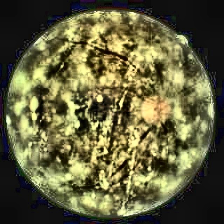

In [ ]:
# load img
img = image.load_img(r"C:\Users\hp\Downloads\Ocular Diseases\clahe_data\train\Diabetic_retinopathy\1240_right_jpeg_jpg.rf.d7d82ca161c53299bc26c60d6d2246e7.jpg",target_size=(224,224,3))
img

In [ ]:
# Convert image into array
array = image.img_to_array(img)

# Scale image
array = array/255

In [ ]:
# Exapnd diamension
array = np.expand_dims(array,axis=0)
img_data = preprocess_input(array)

# Prediction on image data
DCNN.predict(img_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


array([[0.26549056, 0.09919538, 0.4691279 , 0.16618612]], dtype=float32)

In [ ]:
img_pred = np.argmax(dcnn_model.predict(img_data),axis=1)
print("Prediction:",img_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

Prediction: [2]


* Here we can see that our model make correct prediction i.e  Diabetic Retinopathy

## TEST RANDOM IMAGES USING GRADIO

In [3]:
# Load your model
model = load_model('D.keras')

# Define the class names
class_names = ['Cataract','Diabetic Retinopathy','Glaucoma','Normal']

# Create clahe function to enhance the quality of image
def apply_clahe(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)   # Convert to LAB color space
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))  # Apply CLAHE to L-channel
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b)) # Merge the CLAHE enhanced L-channel with the a and b channels
    final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB) # Convert back to RGB color space
    return final

# Preprocess the image
def preprocess_image(image):
    image = cv2.resize(image, (224,224))
    image = apply_clahe(image)
    image = img_to_array(image)
    image = image / 255.0  # Scale pixel values
    image = tf.expand_dims(image, axis=0)  # Add batch dimension
    return image

# Create function for prediction
def predict(image):
    image_np = np.array(image) # Convert PIL Image to numpy array
    clahe_image = apply_clahe(image_np) # Apply CLAHE
    processed_image = preprocess_image(clahe_image) # Preprocess the CLAHE image
    prediction = model.predict(processed_image)  # Make prediction
    class_idx = tf.argmax(prediction, axis=1).numpy()[0]
    confidence = tf.reduce_max(prediction).numpy()
    return clahe_image, class_names[class_idx], f"{confidence:.2f}"

In [7]:
# Create the Gradio interface
iface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type='pil', label='Upload an Image'),
    outputs=[gr.Image(type='numpy', label='CLAHE Processed Image'),
             gr.Label(label='Predicted Class'),
             gr.Textbox(label='Confidence')],
    title='Ocular Disease Classification',
    description='Upload an ocular image to classify it as Normal, Glaucoma, Diabetic Retinopathy, or Cataract. The image will be preprocessed with CLAHE before prediction.')

# Launch the interface
iface.launch(share=True)

Running on local URL:  http://127.0.0.1:7861

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


2024/08/03 14:36:44 [W] [service.go:132] login to server failed: EOF


### INTEGRATE DCNN MODEL WITH XAI

In [10]:
# Load DCNN Model 
model = load_model("D.keras")

# Create function to enhance image using CLAHE
def image_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)  
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final

# Create function to preprocess image
def preprocessing(image_path):
    img = image.load_img(image_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = img.astype(np.uint8)  # Ensure the image is in uint8 format
    img = image_clahe(img)
    img = img.astype(np.float32) / 255.0  # Convert to float32 and normalize
    img_array = np.expand_dims(img, axis=0)
    return img_array

img_path = r"C:\Users\hp\Downloads\ODD NEW\data\test\Diabetic_retinopathy\11364_right_jpeg_jpg.rf.816d60135edbda2c1974544f96132f4f.jpg"
process_image = preprocessing(img_path)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━

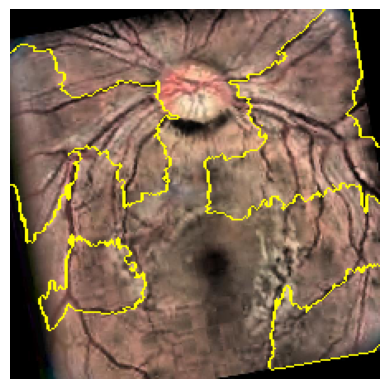

In [11]:
img = image.load_img(img_path, target_size=(224, 224)) # Load the original image with target size
img = image.img_to_array(img).astype(np.uint8)

explainer = lime_image.LimeImageExplainer() # Initialize the LIME explainer

# Define a prediction function
def predict(images):
    images = np.array([image_clahe(img) for img in images])
    images = images.astype(np.float32) / 255.0  # Normalize
    return model.predict(images)

# Generate explanation
explanation = explainer.explain_instance(img, predict, top_labels=1, hide_color=0, num_samples=1000)

# Get the image and mask for the top class
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=10, hide_rest=False)

# Display the explanation
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.axis('off')
plt.show()


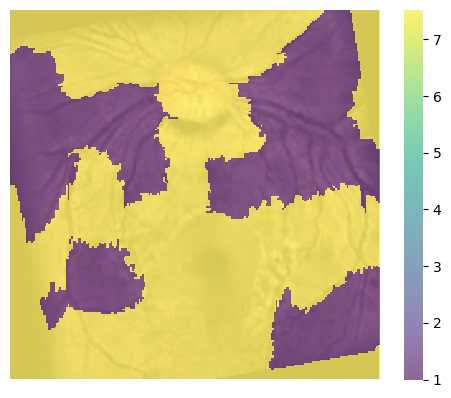

In [12]:
top_label = explanation.top_labels[0] # LIME explanation for the top class

local_explanation = dict(explanation.local_exp[top_label]) # Create a dictionary for the local explanations

heatmap = np.zeros(mask.shape) # Initialize the heatmap with zeros

# Map the superpixel indices to their importance values
for i in range(mask.shape[0]):
    for j in range(mask.shape[1]):
        if mask[i, j] in local_explanation:
            heatmap[i, j] = local_explanation[mask[i, j]]

heatmap /= np.max(heatmap) # Normalize the heatmap

# Plot the heatmap over the original image
fig, ax = plt.subplots()
sns.heatmap(heatmap, cmap='viridis', alpha=0.6, ax=ax, zorder=2, cbar=True)
ax.imshow(img / 255.0, zorder=1, alpha=0.4) # plot orginal image
ax.axis('off')
plt.show()

### Visualize Feature Maps

In [1]:
from keras.models import load_model, Model
from keras.preprocessing.image import load_img, img_to_array
from numpy import expand_dims
from matplotlib import pyplot

In [7]:
# Load your DCNN model
model = load_model('D.keras')

# Redefine the model to output layers for feature extraction
layer_indices = [0, 1, 2, 3] 
outputs = [model.layers[i].output for i in layer_indices]
feature_extraction_model = Model(inputs=model.inputs, outputs=outputs)

# Load and preprocess the image
img = load_img(r"C:\Users\hp\Downloads\ODD NEW\clahe_data\test\Diabetic_retinopathy\11316_right_jpeg_jpg.rf.deb635566a3555fe2f980b0a7b115067.jpg", target_size=(224, 224))  # Adjust target_size if needed
img = img_to_array(img)
img = expand_dims(img, axis=0)
img = img / 255.0  # Normalize image if required

# Get feature maps
feature_maps = feature_extraction_model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


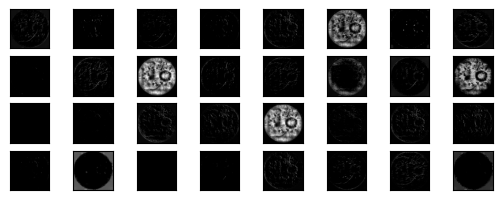

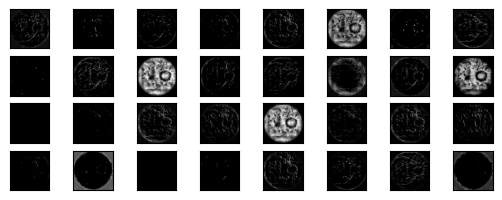

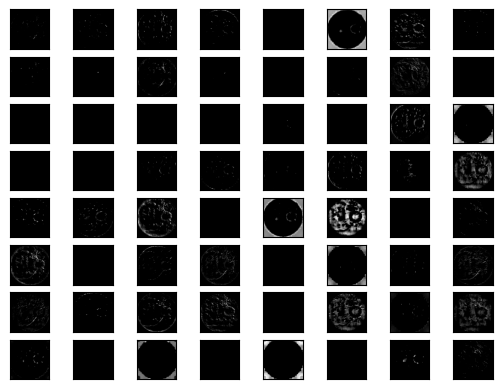

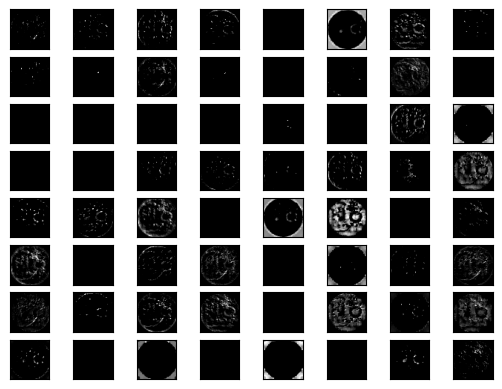

In [13]:
# Plot the output from each selected layer
square = 8
for fmap in feature_maps:
    ix = 1
    for _ in range(square):
        for _ in range(square):
            if ix - 1 < fmap.shape[-1]:
                ax = pyplot.subplot(square, square, ix)
                ax.set_xticks([])
                ax.set_yticks([])
                pyplot.imshow(fmap[0, :, :, ix-1],cmap='gray')
                ix += 1
    pyplot.show()